# Experiment 1A: ISI — Train-at-f / Eval-at-f Protocol (Learnable Tau)

## Overview

This notebook implements Experiment 1A from the "Beyond Beyond Rate" project
under the **train-at-f / eval-at-f** protocol. For each perturbation level *f*
we instantiate a **fresh** SNN (with learnable tau, no delays), train it
end-to-end on ISI with hidden-layer perturbation active on every batch, then
evaluate on the test set at the same *f*.

**Why this protocol:** Section 7.1 of `docs/progress/phase1to4_fixes.md` shows
that applying perturbation only at evaluation (the previous protocol) tells us
how a *clean*-trained network copes with corruption. Training at the same *f*
asks the network to learn the best representation it can given the perturbation,
so the residual accuracy reflects how much temporal information could be
preserved through the perturbed hidden layer.

The hidden-layer perturbation is wired through a **straight-through estimator**
(`_apply_perturbation`) so that ``fc1`` and ``psp_filter`` still receive
gradient signal in the backward pass — the GPU perturbation kernel itself
runs under ``@torch.no_grad()`` and would otherwise sever the autograd graph.

| Property | Value |
|---|---|
| Architecture | Input (10) → Hidden (100, SRMALPHA, learnable tau) → Output (2) |
| Training | Fresh model per *f*; perturbation applied at the 1st hidden layer on every batch |
| Evaluation | Same *f* as training; ``NUM_REPEATS`` repeats for error bars |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

**Interpretation:**
- Smoothly decaying accuracy curve → hidden layer still carries temporal
  structure that the perturbation degrades incrementally.
- Cliff-then-plateau curve → the STE didn't take and ``fc1`` is frozen
  (see Section 7.1 of the fixes doc).
- Compare with `isi_delay.ipynb` to see whether learnable delays change
  the picture.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
import pickle
from typing import Optional

import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
#sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors. We use SRMALPHA neurons
with a 1 ms sampling period and 1000 ms (1 s) sample duration, matching
the ISI dataset time steps.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 44

# --- Train-at-f / eval-at-f sweep ---
# For each f below a fresh model is instantiated from the same seed and
# trained end-to-end with hidden-layer perturbation active on every batch,
# then evaluated on the test set at the same f with NUM_REPEATS repeats.
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3
MODEL_PREFIX = "isi_tau"

## 3. Load ISI Dataset

Load the ISI spike-train dataset from the local HDF5 file.
Each sample has shape `(num_neurons, T)` with binary spike values.

In [3]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]  # (N, num_neurons, T)
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Network config: 10 input neurons, 2 classes


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    # rank[b, c, t] = position of t in the per-(b,c) ascending sort of `key`.
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move  # (B, C, T)

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask  # everything except positions we are keeping
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple[float, float], total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and return train / val / test DataLoaders (no perturbation)."""
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx = get_split_indices(VAL_RANGE, len(X))
    test_idx = get_split_indices(TEST_RANGE, len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a learnable PSP filter (tau).

```
Input (10) → [psp_filter + fc1 + spike] → Hidden (100)
                                              ↓
                          ← perturbation hook (STE) applied here
                                              ↓
                              [psp + fc2 + spike] → Output (2)
```

A single ``forward(x, f)`` method takes the perturbation level and routes
the hidden spikes through ``_apply_perturbation`` — a **straight-through
estimator** that uses the perturbed tensor as the forward value but lets
gradients flow back through the unperturbed ``hidden``. ``f=0`` preserves
the previous unperturbed behaviour exactly.

In [6]:
class ISINetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable tau (PSP filter).

    ``forward(x, f)`` applies the spike-relocation perturbation at the 1st
    hidden layer output through a straight-through estimator so that ``fc1``
    and ``psp_filter`` still receive gradient when training at ``f > 0``.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input → hidden spikes (learnable PSP + fc1 + spike)."""
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes → output spikes (standard PSP + fc2)."""
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """Apply hidden-layer perturbation through a straight-through estimator.

        ``perturb_hidden_batch`` is decorated with ``@torch.no_grad()`` and
        therefore returns a fresh leaf with no edge in the autograd graph.
        Feeding that directly to ``_second_layer`` would block gradient flow
        to ``fc1`` and ``psp_filter`` for any ``f > 0``, freezing them at
        random init (Section 7.1 of ``docs/progress/phase1to4_fixes.md``).
        The STE keeps the perturbed value forward and the identity backward.
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*."""
        x = self._prepare_input(x)
        hidden = self._first_layer(x)
        hidden = self._apply_perturbation(hidden, f)
        return self._second_layer(hidden)

## 7. Training Loop

Train one model end-to-end with perturbation level *f* active on every
training and validation batch. The validation loss used for best-checkpoint
selection sees the same perturbation it will be evaluated under, so the
saved model is the one best at the *perturbed* objective rather than the
clean objective. Standard SLAYER ProbSpikes loss, Nadam optimiser, step-LR
schedule.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
    f: float = 0.0,
) -> tuple["ISINetwork", dict]:
    """Train the ISINetwork end-to-end with perturbation level *f* active.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        epochs: Number of training epochs.
        lr: Learning rate.
        seed: Random seed; re-seeded inside the function so each f-level
            starts from the same initialisation.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISINetwork(num_neurons, num_classes, hidden_units).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5,
    )

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []

    log: dict = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch, f=f)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validate ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()

                    outputs = net(x_batch, f=f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

``test_with_hidden_perturbation`` evaluates a single trained model at a given
*f*. ``test_with_repeats`` wraps it with ``NUM_REPEATS`` independent draws of
the random spike-placement RNG so we get error bars.

Under the train-at-f / eval-at-f protocol these are called once per *f* by
the main sweep loop in §10 (each call uses the model trained at that *f*),
not as a post-hoc sweep over one model.

In [8]:
def test_with_hidden_perturbation(
    net: ISINetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained ISINetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to hidden spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: ISINetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` to obtain mean ± std.

    Each repeat uses a different RNG seed so the random spike placements in
    ``perturb_hidden_batch`` differ; the model itself is fixed.

    Args:
        net: Trained network.
        test_loader: Test DataLoader.
        f: Hidden-layer perturbation level.
        num_repeats: Number of independent evaluations.

    Returns:
        Dict with keys ``mean``, ``std`` and ``values``.
    """
    accuracies: list[float] = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss and tau evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [9]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss and tau evolution for a single run."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    f_val = log.get("f", 0.0)

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"], "s-", label="Val loss", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Training and Validation Loss (f={f_val})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title(f"Learned Tau Over Training (f={f_val})")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(results: dict[float, dict]) -> None:
    """Plot accuracy vs hidden perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
                 color="tab:blue", label="SGD (learnable tau)")
    plt.xlabel("Hidden Perturbation Level (f) — trained & evaluated at this f")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 1A — ISI: Train-at-f / Eval-at-f (Learnable Tau)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_tau_hidden_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_tau_hidden_perturbation.png")

## 10. Run: Train-at-f / Eval-at-f Sweep

For each *f* in ``F_VALUES`` we instantiate a fresh model from ``SEED``,
train it with that perturbation level active on every batch, save the
checkpoint with *f* baked into the filename, then evaluate at the same *f*
with ``NUM_REPEATS`` repeats.

In [10]:
# Build DataLoaders. Perturbation is applied inside the forward pass.
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

all_models: dict[float, ISINetwork] = {}
all_logs: dict[float, dict] = {}
sweep_results: dict[float, dict] = {}

for f_val in F_VALUES:
    print(f"\n=== Training at f={f_val} ===")
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
        f=f_val,
    )

    model_path = f"data/{MODEL_PREFIX}_f{f_val}.pt"
    torch.save(net.state_dict(), model_path)

    result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
    all_models[f_val] = net
    all_logs[f_val] = training_log
    sweep_results[f_val] = result
    print(
        f"f={f_val} | test acc = {result['mean']:.4f} ± {result['std']:.4f}"
        f" | checkpoint -> {model_path}"
    )

Split sizes — Train: 2158, Val: 540, Test: 540

=== Training at f=0.0 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.0:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Train f=0.0: 100%|██████████| 20468/20468 [05:26<00:00, 62.61it/s, best=0.1952, epoch=301, tau=105.0ms, val_loss=0.1970]
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated 

f=0.0 | test acc = 0.9463 ± 0.0000 | checkpoint -> data/isi_tau_f0.0.pt

=== Training at f=0.2 ===


Train f=0.2: 100%|██████████| 20468/20468 [13:56<00:00, 24.46it/s, best=0.1986, epoch=301, tau=111.0ms, val_loss=0.2037]


f=0.2 | test acc = 0.9457 ± 0.0031 | checkpoint -> data/isi_tau_f0.2.pt

=== Training at f=0.4 ===


...

f=0.6 | test acc = 0.9457 ± 0.0009 | checkpoint -> data/isi_tau_f0.6.pt

=== Training at f=0.8 ===


Train f=0.8: 100%|██████████| 20468/20468 [14:00<00:00, 24.36it/s, best=0.1297, epoch=301, tau=147.0ms, val_loss=0.1582]


f=0.8 | test acc = 0.9617 ± 0.0017 | checkpoint -> data/isi_tau_f0.8.pt

=== Training at f=1.0 ===


Train f=1.0: 100%|██████████| 20468/20468 [14:00<00:00, 24.35it/s, best=0.1375, epoch=301, tau=102.0ms, val_loss=0.1708]


f=1.0 | test acc = 0.9617 ± 0.0031 | checkpoint -> data/isi_tau_f1.0.pt


## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. If two `f>0` rows show
bit-identical `fc1.norm`, the upstream layer never received gradient — the
STE wrapper regressed (Issue 1). `hidden_unique` should be `[0.0, 1.0]`
(or `[0.0]`); non-binary values indicate the perturbation hook is seeing
something it cannot apply to (Issue 2).

In [11]:
print(f"{'f':>6}  {'fc1.norm':>10}  {'psp.norm':>10}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    psp_norm = mdl.psp_filter.weight.norm().item()
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        if x_b.dim() == 3:
            x_b = x_b.unsqueeze(2).unsqueeze(3)
        x_b = x_b.to(device).float()
        hidden = mdl._first_layer(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {psp_norm:>10.4f}  {unique}")

     f    fc1.norm    psp.norm  hidden_unique
  0.00    114.4727      5.3795  [0.0, 1.0]
  0.20    114.4682      5.5325  [0.0, 1.0]
  0.40    114.8651      5.3295  [0.0, 1.0]
  0.60    114.2827      5.1010  [0.0, 1.0]
  0.80    114.6967      5.6763  [0.0, 1.0]
  1.00    114.7308      5.3745  [0.0, 1.0]


## 11. Plot Training Curves (per f)

Plot training/validation loss and tau evolution for each trained model.
Useful for spotting an *f* where training diverged or tau collapsed.


--- Training curves at f=0.0 ---


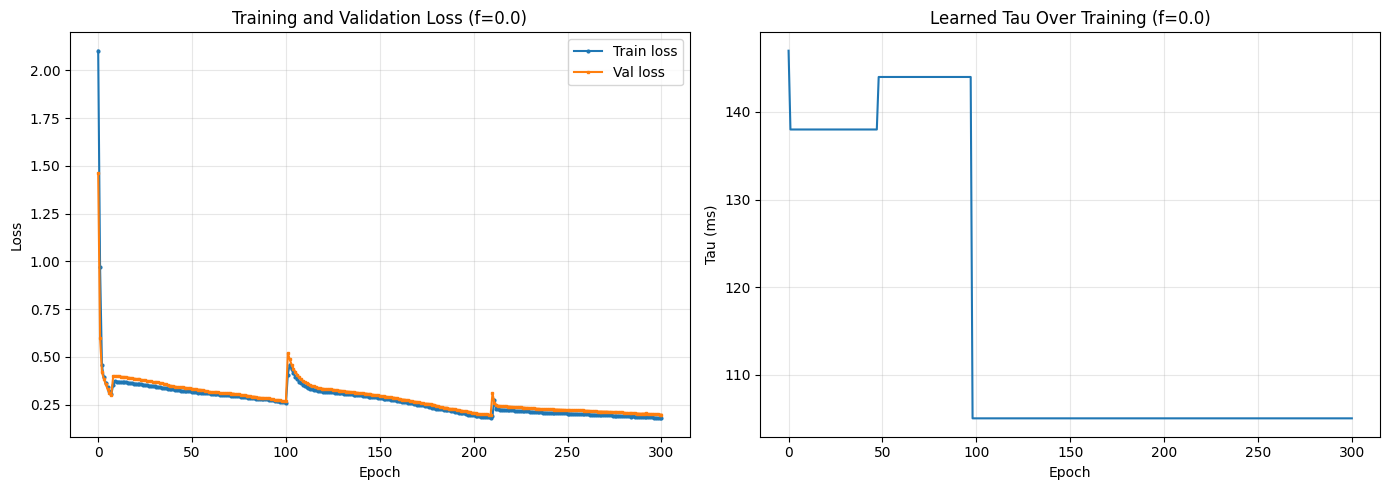


--- Training curves at f=0.2 ---


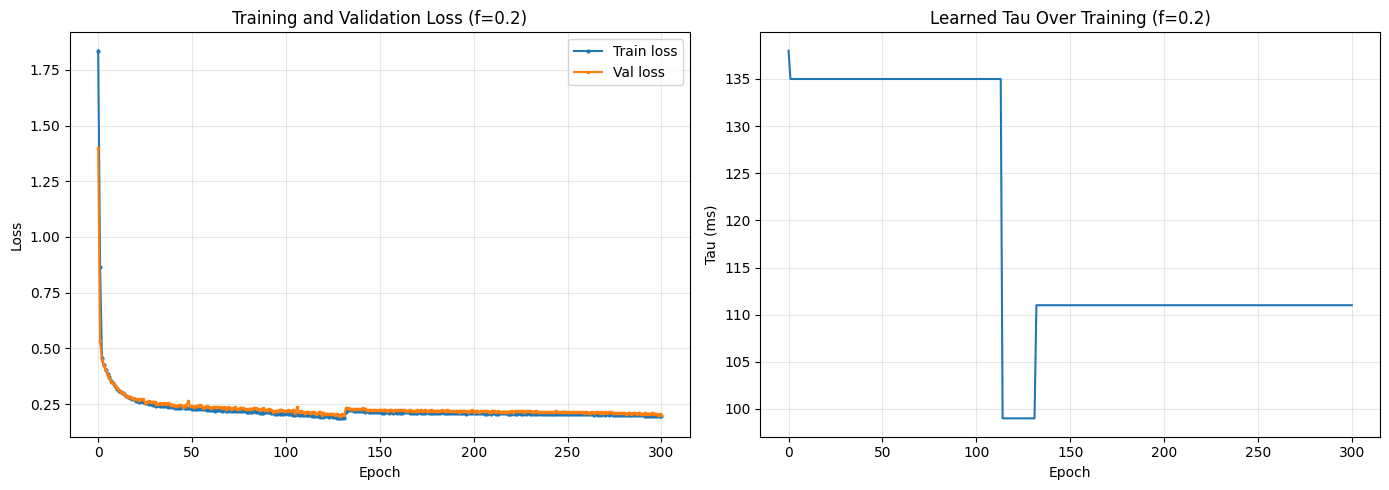


--- Training curves at f=0.4 ---


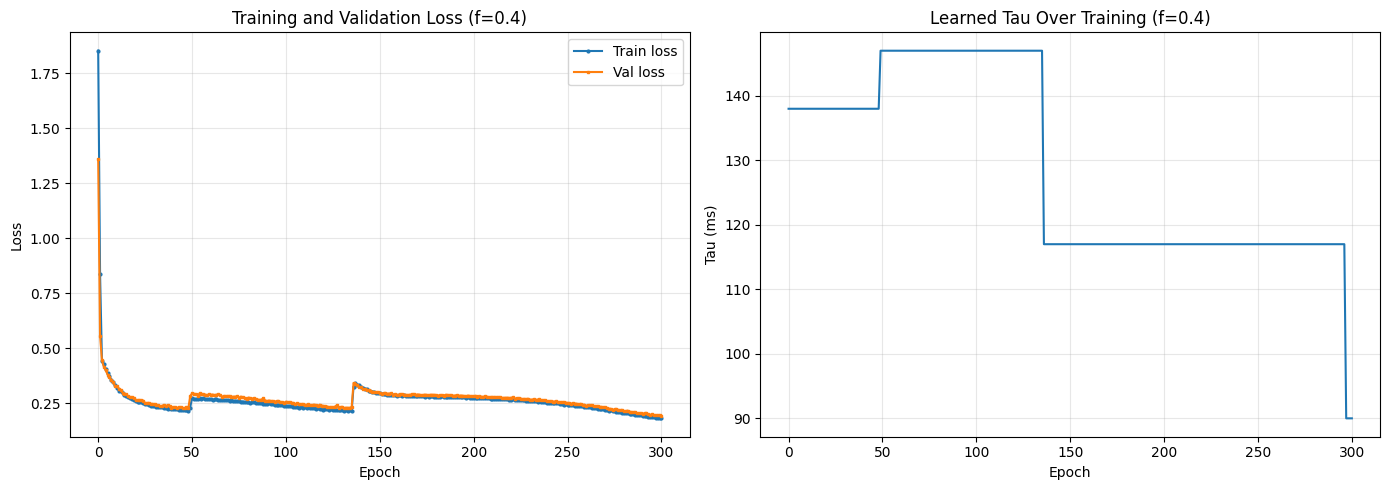


--- Training curves at f=0.6 ---


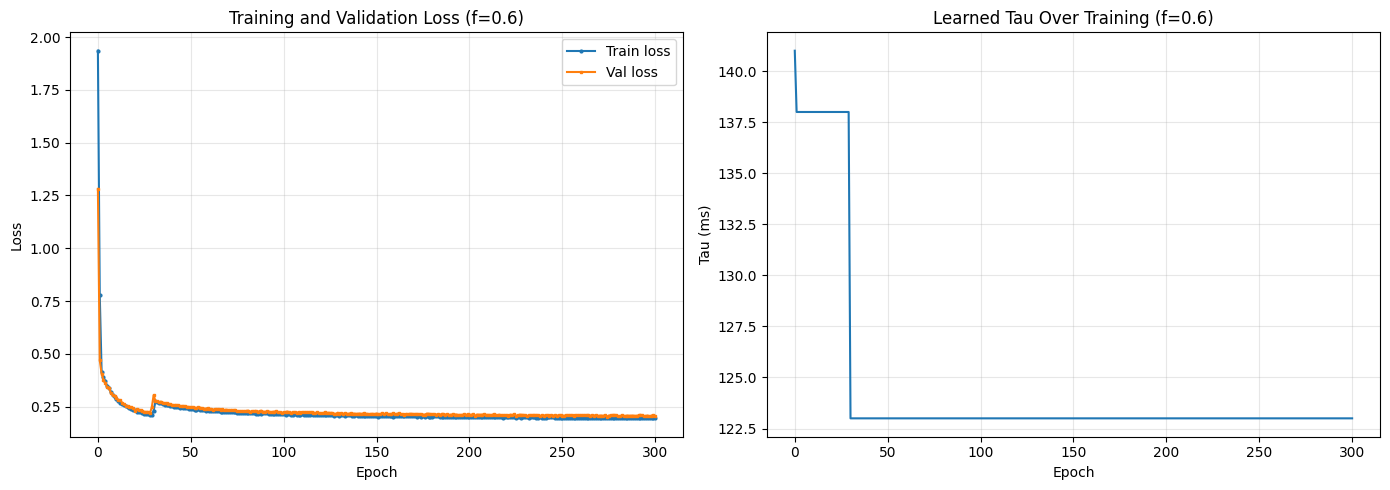


--- Training curves at f=0.8 ---


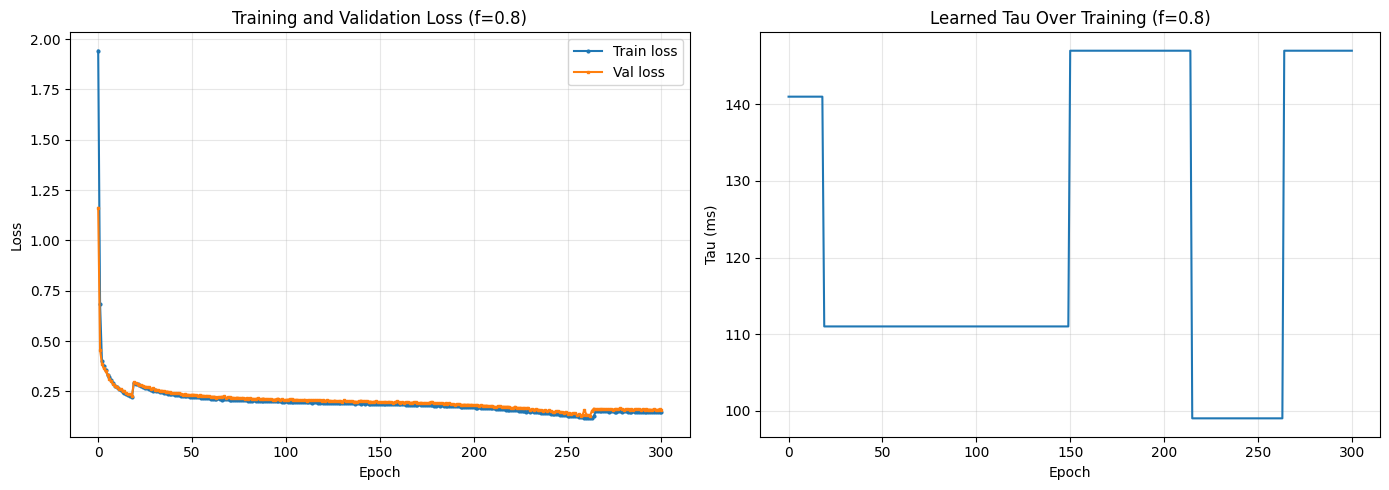


--- Training curves at f=1.0 ---


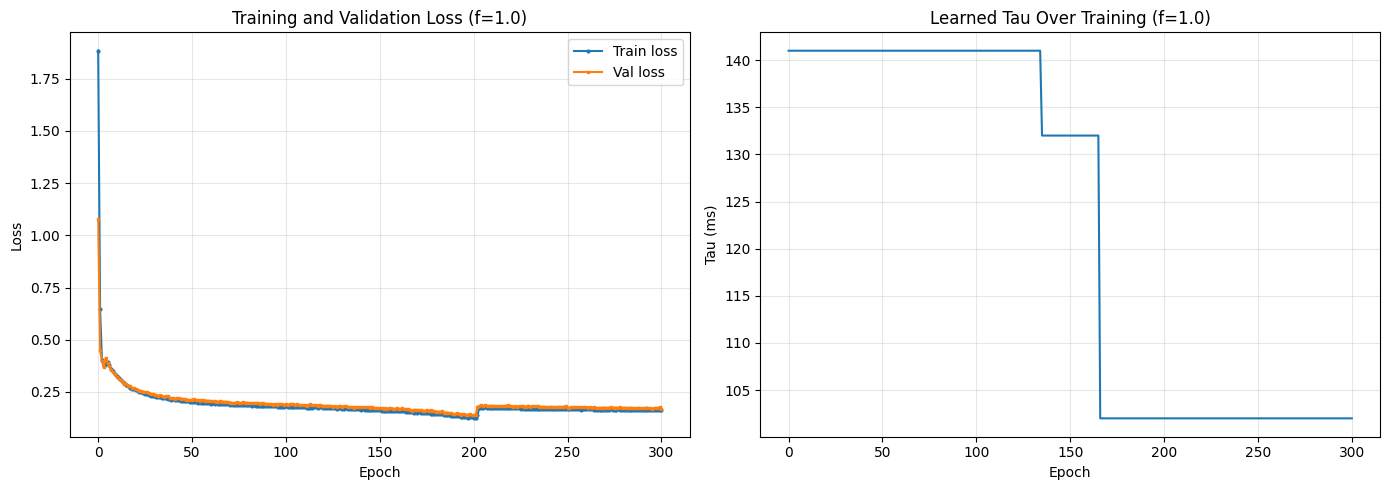

In [12]:
for f_val in F_VALUES:
    print(f"\n--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

The sweep was already executed in §10 — one model trained per *f* and then
evaluated at the same *f*. Print the collected accuracies for inspection
before plotting.

In [13]:
print("=== Train-at-f / Eval-at-f Sweep Summary (ISI, learnable tau) ===")
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {data['mean']:.4f} +/- {data['std']:.4f}")

=== Train-at-f / Eval-at-f Sweep Summary (ISI, learnable tau) ===
  f=0.0:  accuracy = 0.9463 +/- 0.0000
  f=0.2:  accuracy = 0.9457 +/- 0.0031
  f=0.4:  accuracy = 0.9617 +/- 0.0023
  f=0.6:  accuracy = 0.9457 +/- 0.0009
  f=0.8:  accuracy = 0.9617 +/- 0.0017
  f=1.0:  accuracy = 0.9617 +/- 0.0031


## 13. Plot Hidden-Perturbation Results

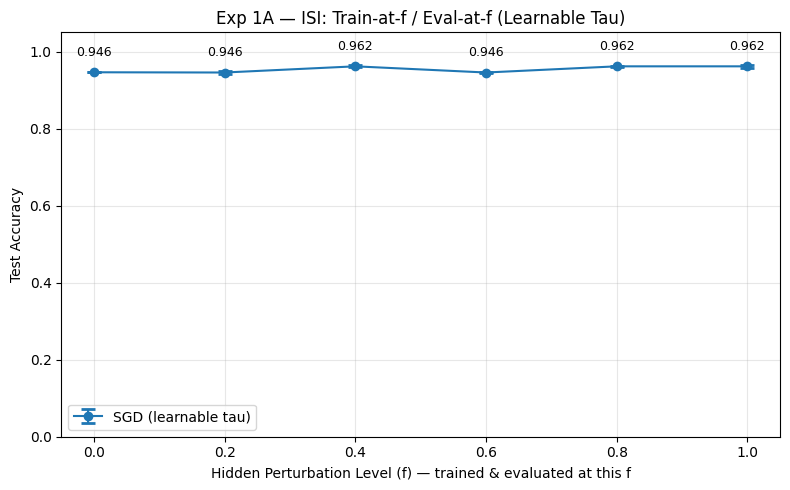

Figure saved to log/isi_tau_hidden_perturbation.png


In [14]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for later
comparison with `isi_delay.ipynb` (SGD-delay model) and with the original
input-perturbation baseline from Beyond Rate.

In [15]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean": float(data["mean"]),
        "std": float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

results_path = f"log/{MODEL_PREFIX}_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save per-f training logs
training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in log.items()
    }
    for f_val, log in all_logs.items()
}
log_path = f"log/{MODEL_PREFIX}_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

Perturbation results saved to log/isi_tau_hidden_perturbation_results.json
Training logs saved to log/isi_tau_training_log.json


## 15. Model Analysis

Inspect the learned tau and PSP filter shape, plus per-layer weight statistics.

=== Learned Parameter Analysis (ISI, learnable tau) ===

     f    effective tau (ms)
   0.0                105.00
   0.2                 99.00
   0.4                 90.00
   0.6                123.00
   0.8                 99.00
   1.0                102.00

f=0 baseline — PSP filter: max=1.0115, mean=0.6996, length=50 taps


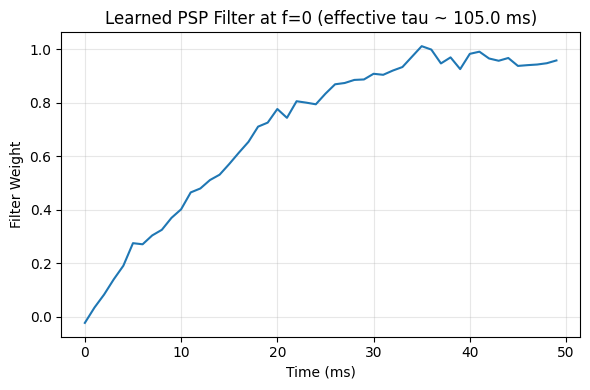


Weight statistics (f=0 baseline):
  fc1.weight_g: mean=5.6579, std=0.8570, shape=[100, 1, 1, 1, 1]
  fc1.weight_v: mean=0.0306, std=1.8112, shape=[100, 10, 1, 1, 1]
  fc2.weight_g: mean=5.9765, std=0.1501, shape=[2, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.0958, std=0.6089, shape=[2, 100, 1, 1, 1]
  psp_filter.weight: mean=0.6996, std=0.3020, shape=[1, 1, 1, 1, 50]


In [16]:
print("=== Learned Parameter Analysis (ISI, learnable tau) ===\n")

print(f"{'f':>6}  {'effective tau (ms)':>20}")
for f_val, mdl in all_models.items():
    print(f"{f_val:>6.1f}  {mdl.get_tau().item() / MS:>20.2f}")

# Detailed PSP filter plot for the f=0 baseline model
baseline = all_models[0.0]
tau_val = baseline.get_tau().item() / MS
filter_weights = baseline.psp_filter.weight.data.squeeze().cpu().numpy()
print(
    f"\nf=0 baseline — PSP filter: max={np.max(np.abs(filter_weights)):.4f}, "
    f"mean={np.mean(filter_weights):.4f}, length={len(filter_weights)} taps"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.flip(filter_weights))
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Filter Weight")
ax.set_title(f"Learned PSP Filter at f=0 (effective tau ~ {tau_val:.1f} ms)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWeight statistics (f=0 baseline):")
for name, param in baseline.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )